# Task 1 — Colab all-in-one run (Aswin)

Upload the **entire repository folder** to the Colab session so the path `task1_llm/member_aswin/` remains intact. Select **Runtime → Change runtime type → GPU**, then run every cell in order. This notebook installs missing packages, discovers the uploaded repository automatically, preprocesses TinyStories, trains the manual character-level GPT, evaluates it, and generates samples.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

config_path = Path(
    "/content/drive/MyDrive/DATA266/lab1/"
    "task1_llm/member_aswin/configs/full.yaml"
)

print("Config found:", config_path.is_file())
print("Path:", config_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config found: True
Path: /content/drive/MyDrive/DATA266/lab1/task1_llm/member_aswin/configs/full.yaml


In [2]:
# Colab/local setup: install only packages that are missing and locate the repository.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

required = {
    'datasets': 'datasets',
    'yaml': 'pyyaml',
    'psutil': 'psutil',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'tqdm': 'tqdm',
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)

import torch
import yaml

def locate_repo_root():
    marker = Path('task1_llm/member_aswin/configs/full.yaml')
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_file():
            return candidate
    content = Path('/content')
    if content.exists():
        matches = list(content.rglob(str(marker)))
        if matches:
            return matches[0].resolve().parents[3]
    # Opening a notebook from Drive does not mount the rest of Drive in Colab.
    try:
        from google.colab import drive
    except ImportError:
        drive = None
    if drive is not None:
        print('Repository not found in /content; mounting Google Drive ...')
        drive.mount('/content/drive')
        drive_root = Path('/content/drive/MyDrive')
        matches = list(drive_root.rglob(str(marker))) if drive_root.exists() else []
        if matches:
            return matches[0].resolve().parents[3]
    raise FileNotFoundError(
        'Could not find task1_llm/member_aswin/configs/full.yaml. '
        'Upload the entire repository folder to /content or place it in My Drive while preserving its structure.'
    )

REPO_ROOT = locate_repo_root()
MEMBER_DIR = REPO_ROOT / 'task1_llm/member_aswin'
SRC_DIR = MEMBER_DIR / 'src'
CONFIG = MEMBER_DIR / 'configs/full.yaml'
os.chdir(REPO_ROOT)

with CONFIG.open(encoding='utf-8') as handle:
    CFG = yaml.safe_load(handle)
RUN_ID = CFG['run_id']

required_files = ['common.py', 'model.py', 'preprocess.py', 'train.py', 'evaluate.py', 'generate.py']
missing_files = [name for name in required_files if not (SRC_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(f'Missing supporting files in {SRC_DIR}: {missing_files}')
if not torch.cuda.is_available():
    raise RuntimeError('No CUDA GPU detected. In Colab choose Runtime > Change runtime type > GPU, then reconnect.')

print(f'Repository: {REPO_ROOT}')
print(f'Run ID:     {RUN_ID}')
print(f'GPU:        {torch.cuda.get_device_name(0)}')
print(f'PyTorch:    {torch.__version__} | CUDA runtime: {torch.version.cuda}')

Repository: /content/drive/MyDrive/DATA266/lab1
Run ID:     full_run01
GPU:        NVIDIA A100-SXM4-40GB
PyTorch:    2.11.0+cu130 | CUDA runtime: 13.0


## 1. Preprocess TinyStories

The cell reuses a complete processed split if it is already present. Delete that run's `data_processed/<run_id>/` folder if you intentionally want to rebuild it.

In [3]:
processed_dir = MEMBER_DIR / 'data_processed' / RUN_ID
processed_files = [processed_dir / name for name in ('train.pt', 'val.pt', 'metadata.json')]
if all(path.is_file() for path in processed_files):
    print(f'Reusing the complete processed split at {processed_dir}')
else:
    subprocess.run(
        [sys.executable, str(SRC_DIR / 'preprocess.py'), '--config', str(CONFIG)],
        cwd=REPO_ROOT,
        check=True,
    )

In [4]:
# Verify split sizes and the required one-character input/target shift.
import json
metadata = json.loads((processed_dir / 'metadata.json').read_text(encoding='utf-8'))
train_sequences = torch.load(processed_dir / 'train.pt', map_location='cpu', weights_only=True)['sequences']
val_sequences = torch.load(processed_dir / 'val.pt', map_location='cpu', weights_only=True)['sequences']
assert train_sequences.shape[0] == CFG['data']['train_examples']
assert val_sequences.shape[0] == CFG['data']['val_examples']
x, y = train_sequences[:2, :-1], train_sequences[:2, 1:]
assert torch.equal(x[:, 1:], y[:, :-1])
print({
    'train_shape': tuple(train_sequences.shape),
    'validation_shape': tuple(val_sequences.shape),
    'vocab_size': metadata['vocab_size'],
    'input_target_shift_verified': True,
})
del train_sequences, val_sequences, x, y

{'train_shape': (100000, 161), 'validation_shape': (10000, 161), 'vocab_size': 111, 'input_target_shift_verified': True}


## 2. Train

A completed checkpoint is reused to prevent an accidental second 12-epoch run. If you are starting a genuinely new experiment, copy `configs/full.yaml`, assign a new `run_id`, and point `CONFIG` to the new file.

In [5]:
checkpoint_dir = MEMBER_DIR / 'checkpoints' / RUN_ID
best_checkpoint = checkpoint_dir / 'best_model.pt'
final_checkpoint = checkpoint_dir / 'final_model.pt'
if best_checkpoint.is_file() and final_checkpoint.is_file():
    print(f'Reusing completed checkpoints in {checkpoint_dir}')
else:
    raw_log = REPO_ROOT / 'reproducibility/raw_logs/task1_llm/aswin' / f'{RUN_ID}.log'
    if raw_log.exists() or best_checkpoint.exists() or final_checkpoint.exists():
        raise RuntimeError(
            f'Run {RUN_ID!r} appears incomplete. To preserve experimental evidence, '
            'copy configs/full.yaml, choose a new run_id, update CONFIG in the setup cell, and rerun.'
        )
    subprocess.run(
        [sys.executable, str(SRC_DIR / 'train.py'), '--config', str(CONFIG)],
        cwd=REPO_ROOT,
        check=True,
    )
assert best_checkpoint.is_file(), f'Training did not produce {best_checkpoint}'

## 3. Evaluate and generate text

In [6]:
for script in ('evaluate.py', 'generate.py'):
    print(f'\nRunning {script} ...')
    subprocess.run(
        [sys.executable, str(SRC_DIR / script), '--config', str(CONFIG)],
        cwd=REPO_ROOT,
        check=True,
    )


Running evaluate.py ...

Running generate.py ...


## 4. Review and save the results

Colab's `/content` storage is temporary. Download the checkpoint, metrics, plots, generated samples, and raw log before ending the session, or upload the repository through Google Drive and copy these artifacts there.

,run_id,run_type,checkpoint,train_ce_loss,val_ce_loss,perplexity,bits_per_char,generalization_gap,top1_next_char_acc,distinct_1,...,max_grad_norm,mean_grad_norm,loss_spikes,nan_count,param_count,train_tokens_per_sec,gen_tokens_per_sec,peak_memory_mb,total_train_time_s,hardware
1,full_run01,full,task1_llm/member_aswin/checkpoints/full_run01/...,0.793211,0.758225,2.134483,1.093887,-0.034986,0.760059,0.016686,...,6.870716,0.720087,125,0,3558960,233568.388959,241.110892,1017.893066,822.016613,NVIDIA A100-SXM4-40GB


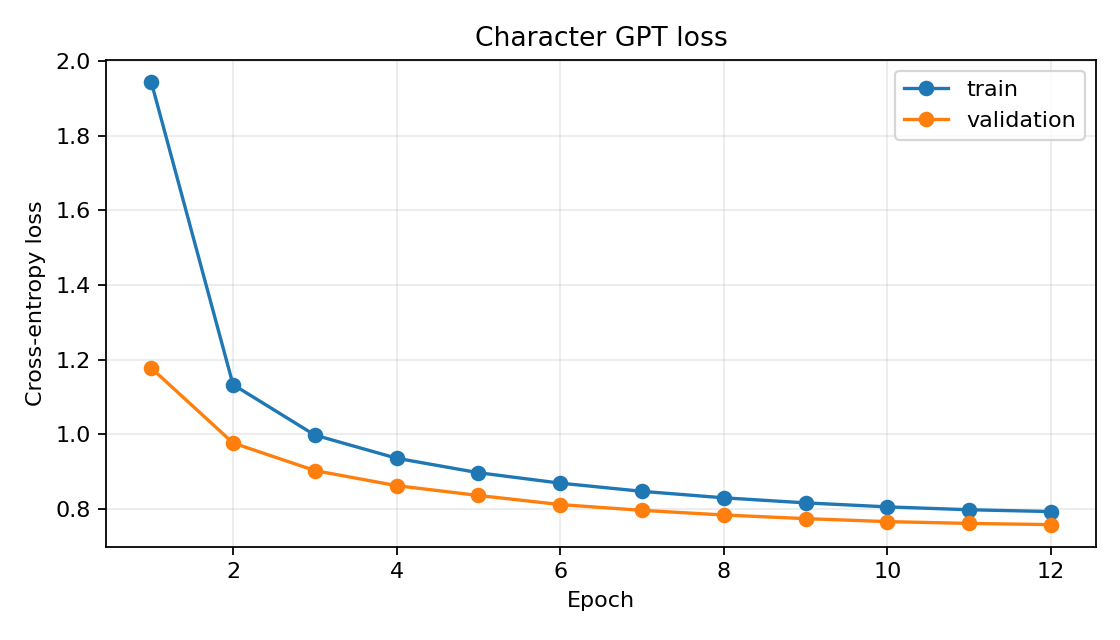

[greedy] Prompt: Once upon a time
Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, she went to the park with her mommy and daddy. She saw a big box of carrots and said, "Lily, you are a good friend. You are a good friend. You are a good friend. You are a good friend. You are a go

[temperature_0.7] Prompt: Once upon a time
Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, she found a big bag of rocks. Lily and Ben were sad because they had a wonderful drink sound. They were so excited, she stuck it on a bush.

[temperature_1.0] Prompt: Once upon a time
Once upon a time, there was a little girl named Lily. She loved to race so much and draw with her parents. One day, she went to her daddy for a hole in the park new place. The mommy said, "Mommy, what's wrong?" 

Mommy laughed and smiled. "My name is Beagle. Can I play with you? Can you stay in your wheels?"

The m

[

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import pandas as pd
from IPython.display import Image, display

metrics_path = MEMBER_DIR / 'metrics_report.csv'
metrics = pd.read_csv(metrics_path)
display(metrics.loc[metrics['run_id'] == RUN_ID])

plot_path = MEMBER_DIR / 'outputs/plots' / f'{RUN_ID}_loss_curves.png'
display(Image(filename=str(plot_path)))

samples_path = MEMBER_DIR / 'outputs/generated_text' / f'{RUN_ID}_samples.txt'
print(samples_path.read_text(encoding='utf-8'))

raw_log = REPO_ROOT / 'reproducibility/raw_logs/task1_llm/aswin' / f'{RUN_ID}.log'
print('\nImportant artifacts to download:')
artifact_paths = [
    best_checkpoint,
    final_checkpoint,
    checkpoint_dir / 'training_history.json',
    checkpoint_dir / 'config.yaml',
    metrics_path,
    plot_path,
    samples_path,
    MEMBER_DIR / 'outputs/generated_text' / f'{RUN_ID}_samples.jsonl',
    raw_log,
]
for path in artifact_paths:
    print(f' - {path}')

# Create one convenient download bundle (processed tensors are intentionally excluded).
import zipfile
from IPython.display import FileLink
bundle_path = REPO_ROOT / f'task1_{RUN_ID}_results.zip'
with zipfile.ZipFile(bundle_path, 'w', compression=zipfile.ZIP_DEFLATED) as bundle:
    for path in artifact_paths:
        if path.is_file():
            bundle.write(path, path.relative_to(REPO_ROOT))
print(f'\nResult bundle: {bundle_path}')
try:
    from google.colab import files as colab_files
    colab_files.download(str(bundle_path))
except ImportError:
    display(FileLink(str(bundle_path)))